# Example-11: Orbit responce

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

import warnings
warnings.simplefilter("ignore", UserWarning)

False


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Orbit responce matrix can be computed using model.make_responce method
# Responce matrix is computed from difference orbits, closed orbits are computed using linear transport matrices

In [4]:
# Set model

model = Model(path='../config.yaml', model='uncoupled', dtype=dtype, device=device)

# Set corrector & monitor locations

lc = model.monitor_index
lm = model.monitor_index

# Set quadrupole errors

kn = 5.0E-3*torch.randn(model.size, dtype=dtype, device=device)
ks = 5.0E-3*torch.randn(model.size, dtype=dtype, device=device)
kl = 0.01

# Set corrector errors (only at corrector locations)

cx = torch.zeros(model.size, dtype=dtype, device=device)
cy = torch.zeros(model.size, dtype=dtype, device=device)

cx[lc] += 1.0E-3*torch.randn(len(lc), dtype=dtype, device=device)
cy[lc] += 1.0E-3*torch.randn(len(lc), dtype=dtype, device=device)

# Make errors

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)

# Make transport

model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

In [5]:
# Compute responce matrix using model transport and transport with errors

responce_model = model.make_responce(lc, lm, model.matrix)
responce_error = model.make_responce(lc, lm, model.matrix_transport)

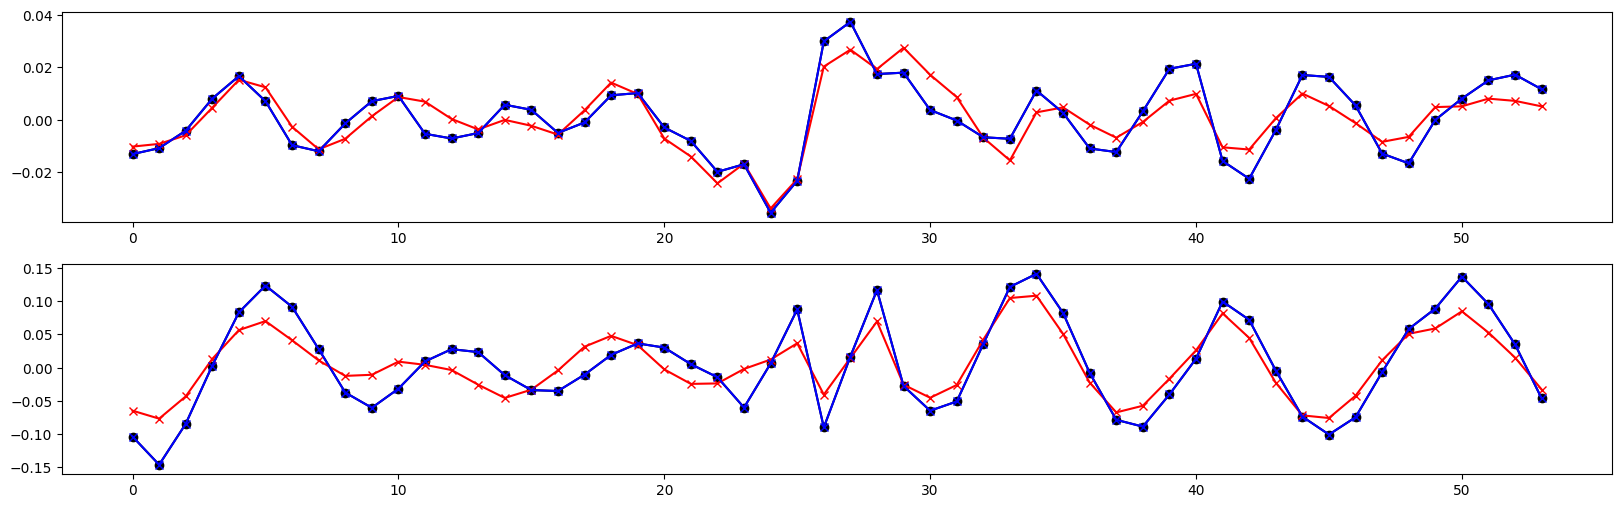

In [6]:
# Compare closed orbits

angle = torch.hstack([cx[lc], cy[lc]])

x_model, y_model = (responce_model @ angle).reshape(2, -1)
x_error, y_error = (responce_error @ angle).reshape(2, -1)

x, _, y, _ = model.orbit[lm].T


plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(range(len(lm)), x, color='black', marker='o')
ax.plot(range(len(lm)), x_model, color='red', marker='x')
ax.plot(range(len(lm)), x_error, color='blue', marker='x')

ax = plt.subplot(212)
ax.plot(range(len(lm)), y, color='black', marker='o')
ax.plot(range(len(lm)), y_model, color='red', marker='x')
ax.plot(range(len(lm)), y_error, color='blue', marker='x')

plt.show()

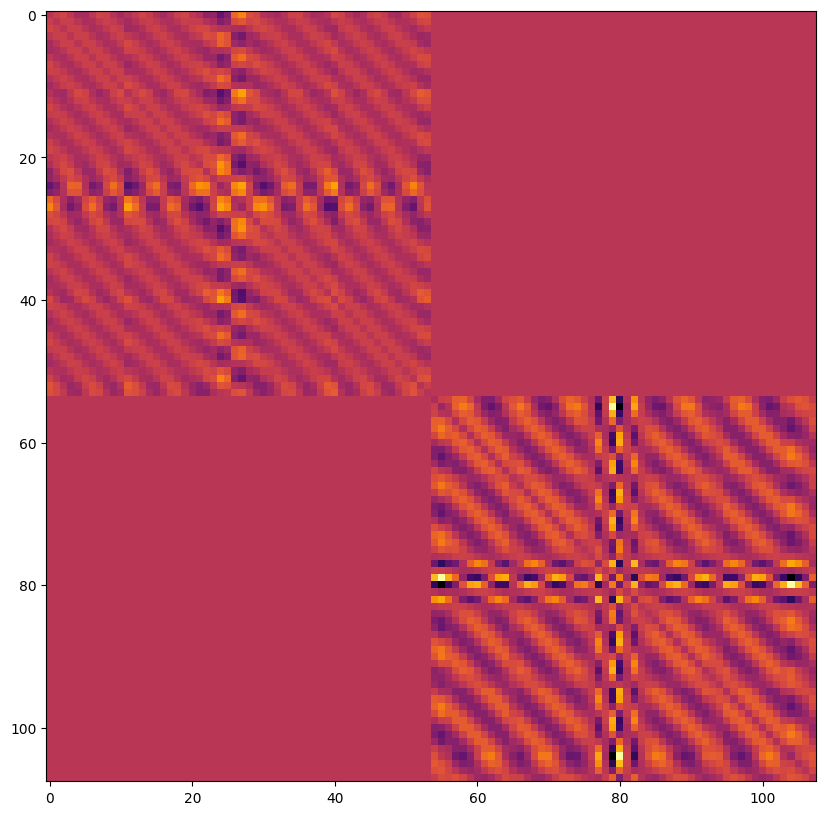

In [7]:
# Plot responce matrix (model)

plt.figure(figsize=(10, 10))
plt.imshow(responce_model.cpu().numpy(), cmap='inferno')
plt.show()

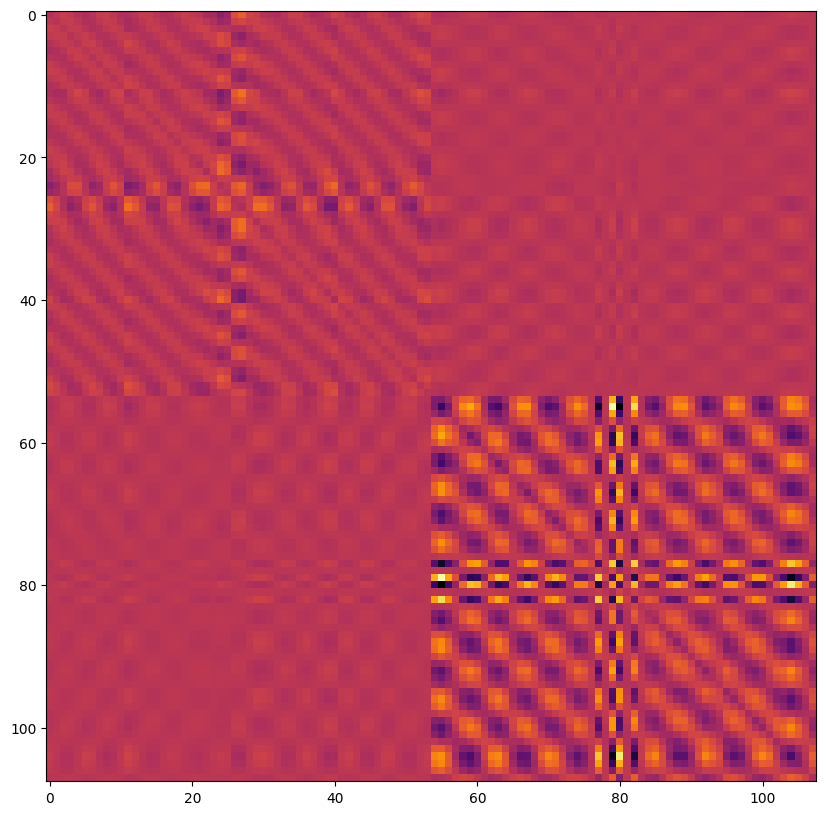

In [8]:
# Plot responce matrix (error)

plt.figure(figsize=(10, 10))
plt.imshow(responce_error.cpu().numpy(), cmap='inferno')
plt.show()